In [13]:
import json
import re
import sys

import matplotlib.pyplot as plt
import matplotlib as mpl
import numpy as np
import pandas as pd
#from nltk.tokenize import word_tokenize
from scipy.optimize import curve_fit
import ast
sys.path.append('../..')
from style_setup import set_thesis_style

set_thesis_style()

### Helper functions

In [14]:
def remove_markdown(sentence):
    """
    Remove markdown formatting from a sentence.
    """
    sentence = re.sub(r'#+', '', sentence)  # Remove all # symbols
    sentence = re.sub(r'\*\*', '', sentence)  # Remove **
    sentence = re.sub(r'\*', '', sentence)  # Remove *
    return sentence

def heaps_law(n, K, beta):
    """Heaps' Law model function."""
    return K * (n ** beta)

def extract_text_from_jsonl(file_path, response_key):
    """
    Extracts and concatenates text from a JSONL file.

    Args:
        file_path (str): The path to the JSONL file.
        response_key (str): The key in the JSON objects that contains the text.

    Returns:
        str: A single string containing all the extracted text.
    """
    all_data = ""
    with open(file_path, "r", encoding='utf-8') as f:
        for line in f:
            try:
                data = json.loads(line)
                if response_key in data:
                    all_data += data[response_key]
            except json.JSONDecodeError:
                print(f"Warning: Could not decode JSON from a line in {file_path}")
    return all_data

def calculate_heaps_parameters(text, sample_step=1000):
    """
    Calculates Heaps' law parameters (K and beta) for a given text.

    Args:
        text (str): The input text.
        sample_step (int): The step size for sampling token counts.

    Returns:
        tuple: A tuple containing (K, beta, N_values, V_values).
    """
    text = remove_markdown(text)
    tokens = word_tokenize(text.lower())

    vocab = set()
    N_values = []
    V_values = []

    for i in range(sample_step, len(tokens) + 1, sample_step):
        current_tokens = tokens[:i]
        vocab.update(current_tokens)
        N_values.append(i)
        V_values.append(len(vocab))

    if not N_values or not V_values:
        return None, None, [], []

    try:
        params, _ = curve_fit(heaps_law, N_values, V_values)
        k, beta = params
        return k, beta, N_values, V_values
    except RuntimeError:
        print("Warning: Could not fit the curve for Heaps' law. Not enough data points?")
        return None, None, N_values, V_values

def process_files_for_heaps(files_to_process):
    """
    Processes a list of files to calculate Heaps' law parameters for each.

    Args:
        files_to_process (list): A list of tuples, where each tuple is
                                 (file_path, response_key, display_name).

    Returns:
        pd.DataFrame: A DataFrame containing the Heaps' law parameters for each file.
    """
    results = []
    for file_path, response_key, name in files_to_process:
        print(f"Processing {name}...")
        text = extract_text_from_jsonl(file_path, response_key)
        if not text:
            print(f"Warning: No text extracted from {file_path}. Skipping.")
            continue
            
        k, beta, N, V = calculate_heaps_parameters(text)
        if k is not None:
            results.append({
                'name': name,
                'k': k,
                'beta': beta,
                'N': N,
                'V': V
            })
    return pd.DataFrame(results)

def plot_heaps_curves(df, title="Heaps' Law: Vocabulary Growth", save_path=None):
    fig, ax = plt.subplots(figsize=(3.33, 2.0))

    max_n = df['N'].apply(lambda x: max(x) if x else 0).max()
    x_range = np.linspace(1, max_n, 500)

    human_rows = df[df['name'].str.lower().str.contains('human')]
    synth_rows = df[~df['name'].str.lower().str.contains('human')]

    # Synthetic envelope
    synth_curves = np.array([
        heaps_law(x_range, row['k'], row['beta'])
        for _, row in synth_rows.iterrows()
        if row['k'] and row['beta']
    ])
    if len(synth_curves):
        synth_mean = synth_curves.mean(axis=0)
        synth_std  = synth_curves.std(axis=0)
        ax.fill_between(x_range,
                        synth_mean - synth_std,
                        synth_mean + synth_std,
                        alpha=0.25, color="#D55E00", label="Synthetic (mean ± 1 SD)")
        ax.plot(x_range, synth_mean, color="#D55E00", linewidth=2.0, linestyle="--")

    # Human line
    for _, row in human_rows.iterrows():
        if row['k'] and row['beta']:
            ax.plot(x_range, heaps_law(x_range, row['k'], row['beta']),
                    color="#0072B2", linewidth=2.5, label=row['name'])

    ax.set_ylabel("Vocabulary Size (V)")
    ax.legend(loc='lower center', bbox_to_anchor=(0.6, 1.01), ncol=2, frameon=True)

    ax.xaxis.set_major_formatter(
        mpl.ticker.FuncFormatter(lambda x, _: f"{x/1e6:.1f}")
    )
    ax.set_xlabel(r"Number of Tokens ($\times 10^6$)")

    fig.tight_layout()
    if save_path:
        fig.savefig(save_path, dpi=300, bbox_inches='tight')
        print(f"Plot saved to: {save_path}")
    plt.show()


# Plot

Plot saved to: /Users/maxschaffelder/Desktop/heaps_law.png


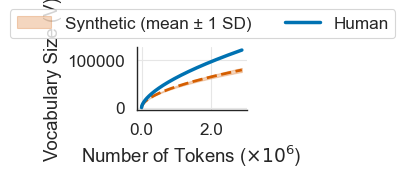

In [15]:
heaps_parameters_df = pd.read_csv("/Users/maxschaffelder/Documents/University/UU/AI Master/Archive/Thesis/data/data_analysis/heaps_law/heaps_parameters_df_final_aggregated.csv")
heaps_parameters_df['N'] = heaps_parameters_df['N'].apply(ast.literal_eval)
heaps_parameters_df['V'] = heaps_parameters_df['V'].apply(ast.literal_eval)

if not heaps_parameters_df.empty:
    plot_heaps_curves(
        heaps_parameters_df,
        save_path="/Users/maxschaffelder/Desktop/heaps_law.png"
    )

# Calculate heaps law parameters

Processing Human 1...
Processing Human 2...
Processing Human 3...
Processing Human 4...
Processing Llama small 1...
Processing Llama small 2...
Processing Llama small 3...
Processing Llama small 4...
Processing Gemma small...
Processing Qwen small...
Processing Falcon small...
Processing Llama medium 1...
Processing Llama medium 2...
Processing Llama medium 3...
Processing Llama medium 4...
Processing Mistral medium...
Processing Qwen medium...
Processing Command medium...
Processing Llama large 1...
Processing Llama large 2...
Processing Llama large 3...
Processing Llama large 4...
Processing Gemini large...
Processing GPT large...
Processing Deepseek large...

Calculated Heaps' Law Parameters:


,name,k,beta
0,Human 1,9.022604,0.644529
1,Human 2,9.710769,0.640290
2,Human 3,8.505578,0.648113
3,Human 4,8.388742,0.649836
4,Llama small 1,19.189088,0.558420
5,Llama small 2,18.862633,0.561900
6,Llama small 3,19.291737,0.558649
7,Llama small 4,17.508655,0.565768
8,Gemma small,27.285780,0.530614
9,Qwen small,22.141020,0.550583


FileNotFoundError: [Errno 2] No such file or directory: '/Users/maxschaffelder/Desktop/Thesis/plots/exp_1/lex_div/heaps/heaps_law_llama_8b.png'

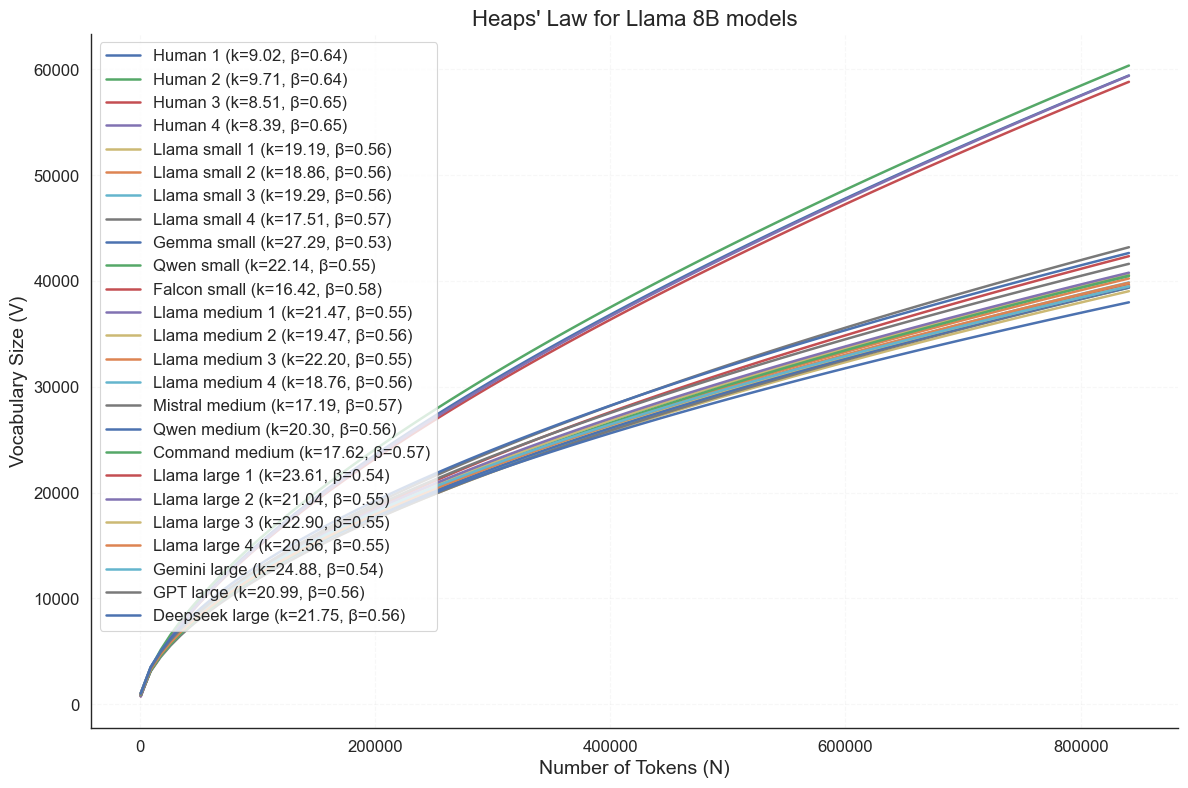

In [7]:
files_to_process = [
    (
        '/Users/maxschaffelder/Desktop/Thesis/data/finetuning/dolly/dolly_train_1.jsonl',
        'response_human', 
        'Human 1'
    ),
    (
        '/Users/maxschaffelder/Desktop/Thesis/data/finetuning/dolly/dolly_train_2.jsonl',
        'response_human', 
        'Human 2'
    ),
    (
        '/Users/maxschaffelder/Desktop/Thesis/data/finetuning/dolly/dolly_train_3.jsonl',
        'response_human', 
        'Human 3'
    ),
    (
        '/Users/maxschaffelder/Desktop/Thesis/data/finetuning/dolly/dolly_train_4.jsonl',
        'response_human', 
        'Human 4'
    ),
    (
        '/Users/maxschaffelder/Desktop/Thesis/data/finetuning/synthetic/Small/Llama/dolly_train_1_Llama.jsonl',
        'response_model',  
        'Llama small 1'
    ),
    (
        '/Users/maxschaffelder/Desktop/Thesis/data/finetuning/synthetic/Small/Llama/dolly_train_2_Llama.jsonl',
        'response_model',  
        'Llama small 2'
    ),
    (
        '/Users/maxschaffelder/Desktop/Thesis/data/finetuning/synthetic/Small/Llama/dolly_train_3_Llama.jsonl',
        'response_model',  
        'Llama small 3'
    ),
    (
        '/Users/maxschaffelder/Desktop/Thesis/data/finetuning/synthetic/Small/Llama/dolly_train_4_Llama.jsonl',
        'response_model',  
        'Llama small 4'
    ),
    (
        '/Users/maxschaffelder/Desktop/Thesis/data/finetuning/synthetic/Small/Other/dolly_train_2_Gemma.jsonl',
        'response_model',  
        'Gemma small'
    ),
    (
        '/Users/maxschaffelder/Desktop/Thesis/data/finetuning/synthetic/Small/Other/dolly_train_3_Qwen2.5-7B-Instruct.jsonl',
        'response_model', 
        'Qwen small'
    ),
    (
        '/Users/maxschaffelder/Desktop/Thesis/data/finetuning/synthetic/Small/Other/dolly_train_4_Falcon3-10B-Instruct.jsonl',
        'response_model', 
        'Falcon small'
    ),
    (
        '/Users/maxschaffelder/Desktop/Thesis/data/finetuning/synthetic/Medium/Llama/dolly_train_1_Llama.jsonl',
        'response_model',  
        'Llama medium 1'
    ),
    (
        '/Users/maxschaffelder/Desktop/Thesis/data/finetuning/synthetic/Medium/Llama/dolly_train_2_Llama.jsonl',
        'response_model',  
        'Llama medium 2'
    ),
    (
        '/Users/maxschaffelder/Desktop/Thesis/data/finetuning/synthetic/Medium/Llama/dolly_train_3_Llama.jsonl',
        'response_model',  
        'Llama medium 3'
    ),
    (
        '/Users/maxschaffelder/Desktop/Thesis/data/finetuning/synthetic/Medium/Llama/dolly_train_4_Llama.jsonl',
        'response_model',  
        'Llama medium 4'
    ),
    (
        '/Users/maxschaffelder/Desktop/Thesis/data/finetuning/synthetic/Medium/Other/dolly_train_2_Mistral.jsonl',
        'response_model', 
        'Mistral medium'
    ),
    (
        '/Users/maxschaffelder/Desktop/Thesis/data/finetuning/synthetic/Medium/Other/dolly_train_3_Qwen.jsonl',
        'response_model', 
        'Qwen medium'
    ),
    (
        '/Users/maxschaffelder/Desktop/Thesis/data/finetuning/synthetic/Medium/Other/dolly_train_4_Command.jsonl',
        'response_model', 
        'Command medium'
    ),
    (
        '/Users/maxschaffelder/Desktop/Thesis/data/finetuning/synthetic/Large/Llama/dolly_train_1_Llama.jsonl',
        'response_model',  
        'Llama large 1'
    ),
    (
        '/Users/maxschaffelder/Desktop/Thesis/data/finetuning/synthetic/Large/Llama/dolly_train_2_Llama.jsonl',
        'response_model',  
        'Llama large 2'
    ),
    (
        '/Users/maxschaffelder/Desktop/Thesis/data/finetuning/synthetic/Large/Llama/dolly_train_3_Llama.jsonl',
        'response_model',  
        'Llama large 3'
    ),
    (
        '/Users/maxschaffelder/Desktop/Thesis/data/finetuning/synthetic/Large/Llama/dolly_train_4_Llama.jsonl',
        'response_model',  
        'Llama large 4'
    ),
    (
        '/Users/maxschaffelder/Desktop/Thesis/data/finetuning/synthetic/Large/Other/dolly_train_2_Gemini.jsonl',
        'response_model', 
        'Gemini large'
    ),
    (
        '/Users/maxschaffelder/Desktop/Thesis/data/finetuning/synthetic/Large/Other/dolly_train_3_GPT.jsonl',
        'response_model', 
        'GPT large'
    ),
    (
        '/Users/maxschaffelder/Desktop/Thesis/data/finetuning/synthetic/Large/Other/dolly_train_4_Deepseek.jsonl',
        'response_model', 
        'Deepseek large'
    ),
]


# Calculate Heaps' law parameters
heaps_parameters_df = process_files_for_heaps(files_to_process)

# Display the results
print("\nCalculated Heaps' Law Parameters:")
display(heaps_parameters_df[['name', 'k', 'beta']])

# Plot the curves
if not heaps_parameters_df.empty:
    plot_heaps_curves(heaps_parameters_df, title="Heaps' Law for Llama 8B models", plot_actual_data=False, save_path='/Users/maxschaffelder/Desktop/Thesis/plots/exp_1/lex_div/heaps/heaps_law_llama_8b.png')


In [24]:
#heaps_parameters_df.to_pickle("/Users/maxschaffelder/Desktop/Thesis/data/data_analysis/heaps_law/heaps_parameters_df_final.pkl")

heaps_parameters_df
heaps_params_only = heaps_parameters_df.copy()
heaps_params_only = heaps_params_only[['name', 'k', 'beta']]

# Create a 'group_name' column by removing the trailing number from 'name'
heaps_params_only['group_name'] = heaps_params_only['name'].str.replace(r' \d+$', '', regex=True)

# Group by the new 'group_name' column and calculate the mean for 'k' and 'beta'
aggregated_params = heaps_params_only.groupby('group_name')[['k', 'beta']].mean()

# Display the aggregated results
display(aggregated_params)

,k,beta
group_name,,
Command medium,17.618716,0.567387
Deepseek large,21.750432,0.555719
Falcon small,16.423275,0.575789
GPT large,20.994635,0.556529
Gemini large,24.881607,0.540228
Gemma small,27.285780,0.530614
Human,8.906923,0.645692
Llama large,22.029180,0.550059
Llama medium,20.474468,0.555443


##  Concatenating datasets for human, llama small, llama medium, llama large

Processing Gemma small...
Processing Qwen small...
Processing Falcon small...
Processing Mistral medium...
Processing Qwen medium...
Processing Command medium...
Processing Gemini large...
Processing GPT large...
Processing Deepseek large...
Processing Human...
Processing Llama small...
Processing Llama medium...
Processing Llama large...

Calculated Heaps' Law Parameters (with aggregated groups):


,name,k,beta
0,Gemma small,27.285780,0.530614
1,Qwen small,22.141020,0.550583
2,Falcon small,16.423275,0.575789
3,Mistral medium,17.191663,0.573889
4,Qwen medium,20.298887,0.555011
5,Command medium,17.618716,0.567387
6,Gemini large,24.881607,0.540228
7,GPT large,20.994635,0.556529
8,Deepseek large,21.750432,0.555719
9,Human,12.505182,0.617752


Plot saved to: /Users/maxschaffelder/Desktop/Thesis/plots/heaps_law/heaps_law_aggregated.png


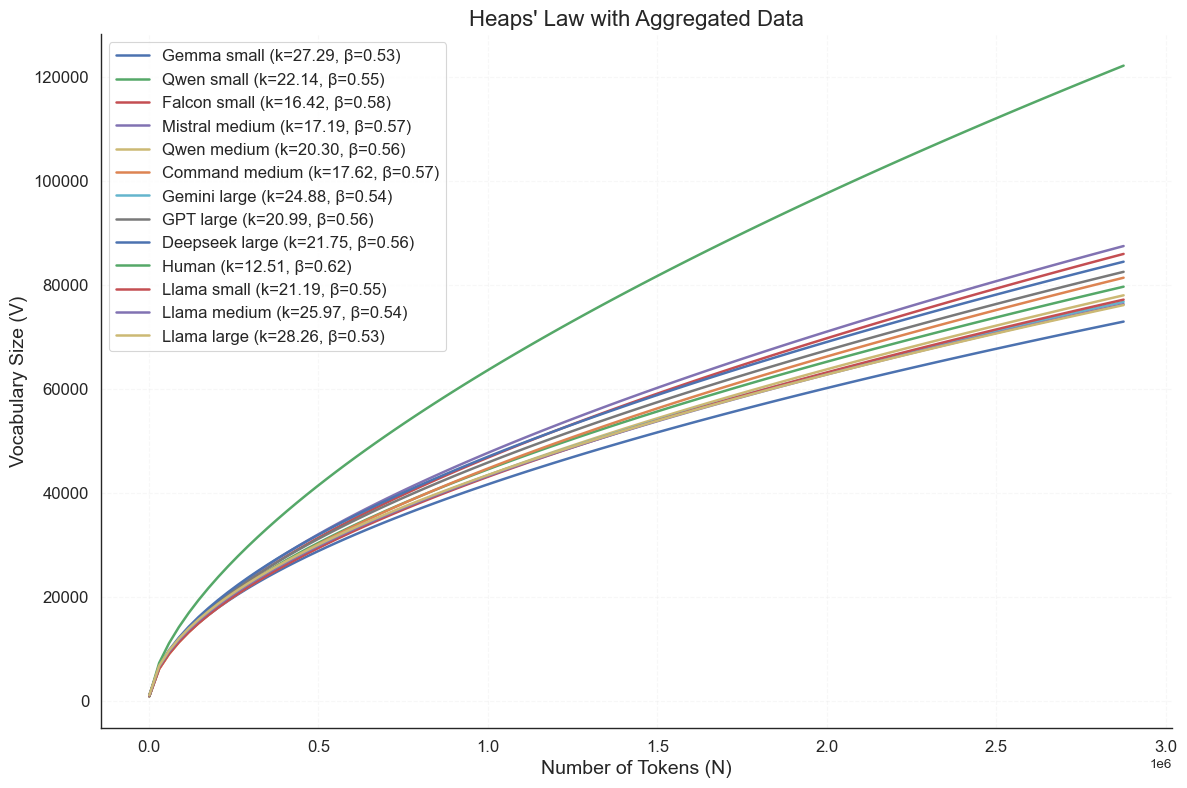


Cleaned up temporary directory: ./temp_concatenated_data


In [25]:
import pandas as pd
import os
import shutil
from collections import defaultdict

# Define the initial list of files and their metadata
files_to_process_definitions = [
    ('/Users/maxschaffelder/Desktop/Thesis/data/finetuning/dolly/dolly_train_1.jsonl', 'response_human', 'Human 1'),
    ('/Users/maxschaffelder/Desktop/Thesis/data/finetuning/dolly/dolly_train_2.jsonl', 'response_human', 'Human 2'),
    ('/Users/maxschaffelder/Desktop/Thesis/data/finetuning/dolly/dolly_train_3.jsonl', 'response_human', 'Human 3'),
    ('/Users/maxschaffelder/Desktop/Thesis/data/finetuning/dolly/dolly_train_4.jsonl', 'response_human', 'Human 4'),
    ('/Users/maxschaffelder/Desktop/Thesis/data/finetuning/synthetic/Small/Llama/dolly_train_1_Llama.jsonl', 'response_model', 'Llama small 1'),
    ('/Users/maxschaffelder/Desktop/Thesis/data/finetuning/synthetic/Small/Llama/dolly_train_2_Llama.jsonl', 'response_model', 'Llama small 2'),
    ('/Users/maxschaffelder/Desktop/Thesis/data/finetuning/synthetic/Small/Llama/dolly_train_3_Llama.jsonl', 'response_model', 'Llama small 3'),
    ('/Users/maxschaffelder/Desktop/Thesis/data/finetuning/synthetic/Small/Llama/dolly_train_4_Llama.jsonl', 'response_model', 'Llama small 4'),
    ('/Users/maxschaffelder/Desktop/Thesis/data/finetuning/synthetic/Small/Other/dolly_train_2_Gemma.jsonl', 'response_model', 'Gemma small'),
    ('/Users/maxschaffelder/Desktop/Thesis/data/finetuning/synthetic/Small/Other/dolly_train_3_Qwen2.5-7B-Instruct.jsonl', 'response_model', 'Qwen small'),
    ('/Users/maxschaffelder/Desktop/Thesis/data/finetuning/synthetic/Small/Other/dolly_train_4_Falcon3-10B-Instruct.jsonl', 'response_model', 'Falcon small'),
    ('/Users/maxschaffelder/Desktop/Thesis/data/finetuning/synthetic/Medium/Llama/dolly_train_1_Llama.jsonl', 'response_model', 'Llama medium 1'),
    ('/Users/maxschaffelder/Desktop/Thesis/data/finetuning/synthetic/Medium/Llama/dolly_train_2_Llama.jsonl', 'response_model', 'Llama medium 2'),
    ('/Users/maxschaffelder/Desktop/Thesis/data/finetuning/synthetic/Medium/Llama/dolly_train_3_Llama.jsonl', 'response_model', 'Llama medium 3'),
    ('/Users/maxschaffelder/Desktop/Thesis/data/finetuning/synthetic/Medium/Llama/dolly_train_4_Llama.jsonl', 'response_model', 'Llama medium 4'),
    ('/Users/maxschaffelder/Desktop/Thesis/data/finetuning/synthetic/Medium/Other/dolly_train_2_Mistral.jsonl', 'response_model', 'Mistral medium'),
    ('/Users/maxschaffelder/Desktop/Thesis/data/finetuning/synthetic/Medium/Other/dolly_train_3_Qwen.jsonl', 'response_model', 'Qwen medium'),
    ('/Users/maxschaffelder/Desktop/Thesis/data/finetuning/synthetic/Medium/Other/dolly_train_4_Command.jsonl', 'response_model', 'Command medium'),
    ('/Users/maxschaffelder/Desktop/Thesis/data/finetuning/synthetic/Large/Llama/dolly_train_1_Llama.jsonl', 'response_model', 'Llama large 1'),
    ('/Users/maxschaffelder/Desktop/Thesis/data/finetuning/synthetic/Large/Llama/dolly_train_2_Llama.jsonl', 'response_model', 'Llama large 2'),
    ('/Users/maxschaffelder/Desktop/Thesis/data/finetuning/synthetic/Large/Llama/dolly_train_3_Llama.jsonl', 'response_model', 'Llama large 3'),
    ('/Users/maxschaffelder/Desktop/Thesis/data/finetuning/synthetic/Large/Llama/dolly_train_4_Llama.jsonl', 'response_model', 'Llama large 4'),
    ('/Users/maxschaffelder/Desktop/Thesis/data/finetuning/synthetic/Large/Other/dolly_train_2_Gemini.jsonl', 'response_model', 'Gemini large'),
    ('/Users/maxschaffelder/Desktop/Thesis/data/finetuning/synthetic/Large/Other/dolly_train_3_GPT.jsonl', 'response_model', 'GPT large'),
    ('/Users/maxschaffelder/Desktop/Thesis/data/finetuning/synthetic/Large/Other/dolly_train_4_Deepseek.jsonl', 'response_model', 'Deepseek large'),
]

# --- Aggregation Logic ---

# 1. Setup a temporary directory for concatenated files
temp_dir = "./temp_concatenated_data"
if os.path.exists(temp_dir):
    shutil.rmtree(temp_dir)
os.makedirs(temp_dir)

# 2. Define groups and categorize files
group_patterns = {"Human": "Human", "Llama small": "Llama small", "Llama medium": "Llama medium", "Llama large": "Llama large"}
grouped_files = defaultdict(lambda: {"paths": [], "column": None})
individual_files = []

for file_path, column, name in files_to_process_definitions:
    matched_group = None
    for pattern, group_name in group_patterns.items():
        if name.startswith(pattern):
            matched_group = group_name
            break
    
    if matched_group:
        grouped_files[matched_group]["paths"].append(file_path)
        grouped_files[matched_group]["column"] = column
    else:
        individual_files.append((file_path, column, name))

# 3. Concatenate files for each group and save them temporarily
aggregated_files_to_process = list(individual_files) # Start with non-grouped files

for group_name, data in grouped_files.items():
    concatenated_df = pd.concat(
        [pd.read_json(p, lines=True) for p in data["paths"]],
        ignore_index=True
    )
    
    temp_filepath = os.path.join(temp_dir, f"{group_name.replace(' ', '_')}.jsonl")
    concatenated_df.to_json(temp_filepath, orient='records', lines=True)
    
    # Add the new aggregated file to the list for processing
    aggregated_files_to_process.append((temp_filepath, data["column"], group_name))

# --- Processing and Plotting ---

# Calculate Heaps' law parameters using the new list of aggregated files
heaps_parameters_df = process_files_for_heaps(aggregated_files_to_process)

# Display the results
print("\nCalculated Heaps' Law Parameters (with aggregated groups):")
display(heaps_parameters_df[['name', 'k', 'beta']])

# Plot the curves
if not heaps_parameters_df.empty:
    plot_heaps_curves(
        heaps_parameters_df, 
        title="Heaps' Law with Aggregated Data", 
        plot_actual_data=False, 
        save_path='/Users/maxschaffelder/Desktop/Thesis/plots/heaps_law/heaps_law_aggregated.png'
    )

# --- Cleanup ---
# Remove the temporary directory and its contents
shutil.rmtree(temp_dir)
print(f"\nCleaned up temporary directory: {temp_dir}")

In [26]:
heaps_parameters_df.to_csv("/Users/maxschaffelder/Desktop/Thesis/data/data_analysis/heaps_law/heaps_parameters_df_final_aggregated.csv")

Plot saved to: /Users/maxschaffelder/Desktop/heaps_law_aggregate_v2.png


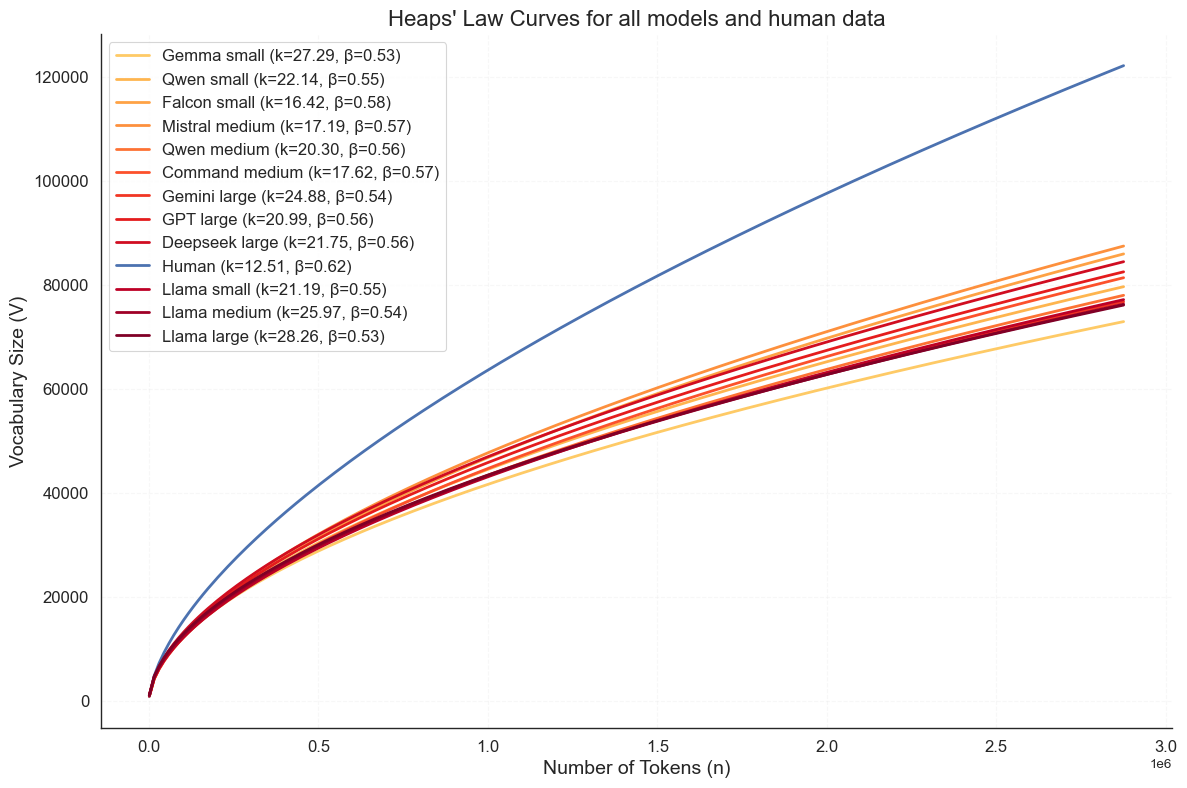

In [9]:
heaps_parameters_df = pd.read_csv("/Users/maxschaffelder/Desktop/Thesis/data/data_analysis/heaps_law/heaps_parameters_df_final_aggregated.csv")
heaps_parameters_df['N'] = heaps_parameters_df['N'].apply(ast.literal_eval)
heaps_parameters_df['V'] = heaps_parameters_df['V'].apply(ast.literal_eval)
# Plot the curves
if not heaps_parameters_df.empty:
    plot_heaps_curves(
        heaps_parameters_df, 
        title="Heaps' Law Curves for all models and human data", 
        plot_actual_data=False, 
        save_path='/Users/maxschaffelder/Desktop/heaps_law_aggregate_v2.png'
    )

In [5]:
print(heaps_parameters_df[['name', 'k', 'beta']])


              name          k      beta
0      Gemma small  27.285780  0.530614
1       Qwen small  22.141020  0.550583
2     Falcon small  16.423275  0.575789
3   Mistral medium  17.191663  0.573889
4      Qwen medium  20.298887  0.555011
5   Command medium  17.618716  0.567387
6     Gemini large  24.881607  0.540228
7        GPT large  20.994635  0.556529
8   Deepseek large  21.750432  0.555719
9            Human  12.505182  0.617752
10     Llama small  21.191212  0.551397
11    Llama medium  25.966470  0.536964
12     Llama large  28.260131  0.531123


In [10]:
import pandas as pd
heaps_copy = heaps_parameters_df.copy()
# Define the desired order for sizes
size_order = ['small', 'medium', 'large']

# Create a 'size' column with a categorical type to enforce the sorting order
# This extracts 'small', 'medium', or 'large' from the 'name' column
heaps_copy['size'] = pd.Categorical(
    heaps_copy['name'].str.extract(r'(small|medium|large)')[0],
    categories=size_order,
    ordered=True
)

# Create a helper column to prioritize the 'Human' entry
heaps_copy['sort_prio_human'] = heaps_copy['name'].apply(
    lambda x: 0 if x == 'Human' else 1
)

# Create a helper column to prioritize 'Llama' entries within each size group
heaps_copy['sort_prio_llama'] = heaps_copy['name'].apply(
    lambda x: 0 if 'Llama' in x else 1
)

# Sort the DataFrame based on the custom priorities and then by name as a tie-breaker
heaps_copy_sorted = heaps_copy.sort_values(
    by=['sort_prio_human', 'size', 'sort_prio_llama', 'name']
).reset_index(drop=True)

# Remove the temporary columns used for sorting
heaps_copy_sorted = heaps_copy_sorted.drop(
    columns=['size', 'sort_prio_human', 'sort_prio_llama']
)

# Display the reordered DataFrame
print("Reordered DataFrame:")
display(heaps_copy_sorted)

Reordered DataFrame:


,Unnamed: 0,name,k,beta,N,V
0,9,Human,12.505182,0.617752,"[1000, 2000, 3000, 4000, 5000, 6000, 7000, 800...","[411, 784, 1141, 1467, 1783, 2038, 2276, 2533,..."
1,10,Llama small,21.191212,0.551397,"[1000, 2000, 3000, 4000, 5000, 6000, 7000, 800...","[355, 677, 959, 1235, 1453, 1716, 1909, 2128, ..."
2,2,Falcon small,16.423275,0.575789,"[1000, 2000, 3000, 4000, 5000, 6000, 7000, 800...","[488, 830, 1124, 1399, 1666, 1927, 2166, 2421,..."
3,0,Gemma small,27.285780,0.530614,"[1000, 2000, 3000, 4000, 5000, 6000, 7000, 800...","[467, 817, 1125, 1404, 1679, 1914, 2167, 2354,..."
4,1,Qwen small,22.141020,0.550583,"[1000, 2000, 3000, 4000, 5000, 6000, 7000, 800...","[453, 807, 1119, 1409, 1700, 1881, 2089, 2329,..."
5,11,Llama medium,25.966470,0.536964,"[1000, 2000, 3000, 4000, 5000, 6000, 7000, 800...","[409, 737, 979, 1244, 1459, 1708, 1905, 2156, ..."
6,5,Command medium,17.618716,0.567387,"[1000, 2000, 3000, 4000, 5000, 6000, 7000, 800...","[455, 792, 1093, 1355, 1623, 1849, 2069, 2341,..."
7,3,Mistral medium,17.191663,0.573889,"[1000, 2000, 3000, 4000, 5000, 6000, 7000, 800...","[445, 766, 1076, 1373, 1635, 1858, 2101, 2335,..."
8,4,Qwen medium,20.298887,0.555011,"[1000, 2000, 3000, 4000, 5000, 6000, 7000, 800...","[411, 751, 1026, 1306, 1494, 1790, 1940, 2120,..."
9,12,Llama large,28.260131,0.531123,"[1000, 2000, 3000, 4000, 5000, 6000, 7000, 800...","[398, 708, 978, 1278, 1513, 1765, 2031, 2209, ..."


Plot saved to: /Users/maxschaffelder/Desktop/heaps_law_aggregate_v2.png


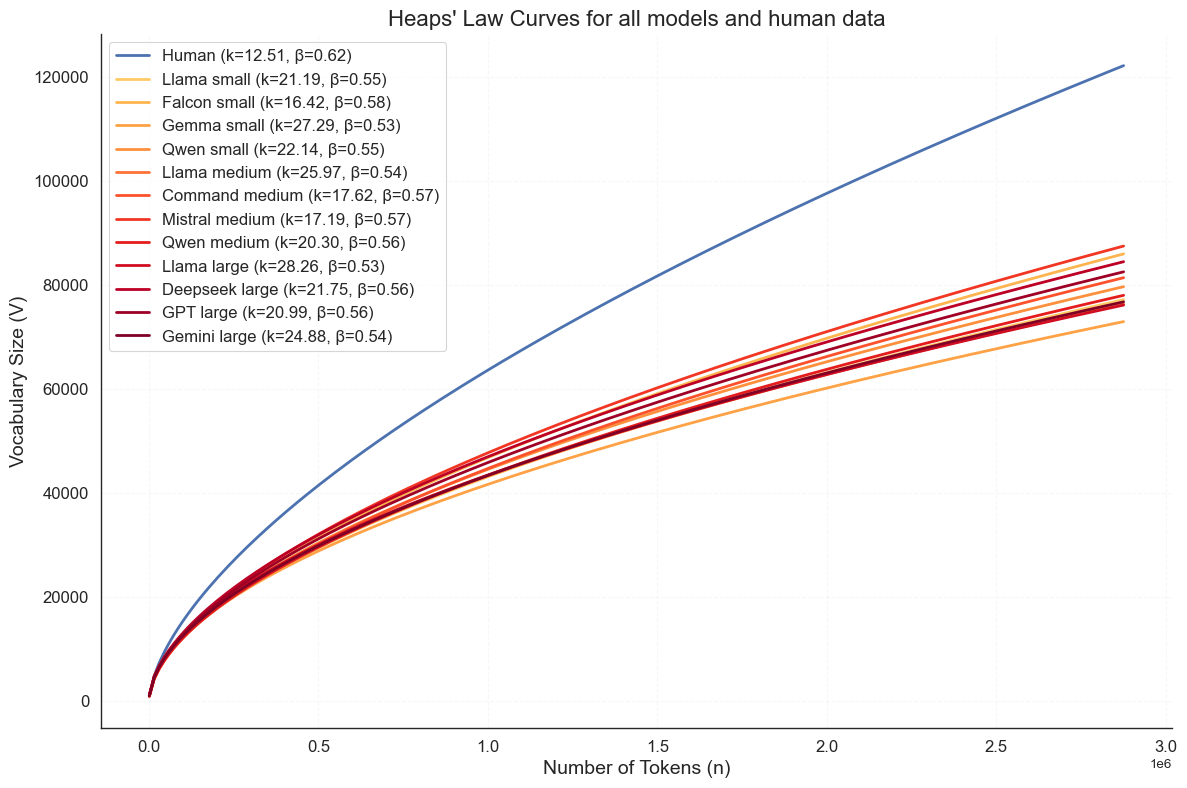

In [12]:
# Plot the curves
if not heaps_copy_sorted.empty:
    plot_heaps_curves(
        heaps_copy_sorted, 
        title="Heaps' Law Curves for all models and human data", 
        plot_actual_data=False, 
        save_path='/Users/maxschaffelder/Desktop/heaps_law_aggregate_v2.png'
    )